# Spotify Customer Churn Analysis: Exploratory Data Analysis

## Project Objective

Customer churn is a major challenge for subscription-based businesses such as Spotify. Understanding which customer characteristics and listening behaviors are associated with churn can help improve customer retention and reduce revenue loss.

The purpose of this exploratory data analysis (EDA) is to:

- Explore customer demographics and listening behavior
- Investigate relationships between features and churn
- Identify variables that may be useful predictors in future machine learning models

Data cleaning and validation were completed in a separate Data Wrangling notebook. This notebook focuses exclusively on exploratory analysis.

In [1]:
# Import libraries used for exploratory analysis and visualization.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport
%matplotlib inline

# Load the cleaned Spotify churn dataset.

spotify_df = pd.read_csv("spotify_churn_cleaned.csv")

# Display the first five records.

spotify_df.head()

E:\TEMP\ipykernel_26124\1396332587.py:9: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


# Dataset Profiling

A YData Profile Report will be generated to provide a high-level overview of the dataset.

The profile report summarizes:

- Variable distributions
- Summary statistics
- Correlations
- Missing values
- Duplicate records

The report will be used as a reference point for the exploratory analysis that follows.

In [2]:
# Generate and display the profile report directly in the notebook.

profile = ProfileReport(
    spotify_df,
    title="Spotify Customer Churn Profile Report",
    explorative=True
)

profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 662.82it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

The YData profile report indicated:

- 74.1% retained customers
- 25.9% churned customers
- No missing values
- No duplicate records
- Potential relationships among subscription type, offline listening, and advertisement exposure.

# Subscription Type and Customer Churn

The YData profile identified subscription type as a potentially important variable.

This analysis examines whether churn rates differ across Spotify subscription plans.

In [5]:
# Calculate churn percentages by subscription type.

pd.crosstab(
    spotify_df['subscription_type'],
    spotify_df['is_churned'],
    normalize='index'
) * 100

is_churned,0,1
subscription_type,,
Family,72.484277,27.515723
Free,75.074331,24.925669
Premium,74.940898,25.059102
Student,73.813170,26.186830


## Findings

Customer churn rates were relatively consistent across all subscription types.

Family subscribers exhibited the highest churn rate (27.5%), while Free subscribers exhibited the lowest churn rate (24.9%). However, the differences between subscription types were small.

Based on this analysis, subscription type does not appear to be a strong independent predictor of customer churn.

# Offline Listening and Customer Churn

Offline listening was identified by the YData profile as a potentially important variable.

This analysis examines whether churn rates differ between customers who utilize offline listening and those who do not.

In [6]:
# Calculate churn percentages by offline listening status.

pd.crosstab(
    spotify_df['offline_listening'],
    spotify_df['is_churned'],
    normalize='index'
) * 100

is_churned,0,1
offline_listening,,
0,75.074331,24.925669
1,73.788031,26.211969


## Findings

Customers who utilized offline listening exhibited a slightly higher churn rate (26.2%) than customers who did not utilize offline listening (24.9%).

However, the difference between groups was relatively small, suggesting that offline listening alone may not be a strong predictor of customer churn.

Further analysis is needed to determine whether offline listening interacts with other customer characteristics or listening behaviors.

# Numerical Features and Customer Churn

The following analysis examines whether customer listening behaviors differ between retained and churned customers.

Boxplots are used to compare the distribution and central tendency of each numerical variable across churn groups.

Variables exhibiting meaningful differences between groups may be useful predictors in future machine learning models.

In [7]:
# Compare average numerical values between retained and churned customers.

numeric_cols = [
    'age',
    'listening_time',
    'songs_played_per_day',
    'skip_rate',
    'ads_listened_per_week'
]

spotify_df.groupby('is_churned')[numeric_cols].mean()

,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week
is_churned,,,,,
0,37.632147,154.446787,49.970653,0.298474,6.962220
1,37.747948,152.984549,50.575567,0.304862,6.891357


## Findings

The average values for the numerical variables were very similar between retained and churned customers.

Only minor differences were observed across age, listening time, songs played per day, skip rate, and advertisements listened per week.

These results suggest that individual numerical variables may have limited predictive power when considered independently. Additional analysis is needed to determine whether combinations of variables or categorical features exhibit stronger relationships with customer churn.

In [8]:
# Calculate Pearson correlation coefficients for numerical variables.
# Correlation analysis helps identify linear relationships between
# features and the target variable.

corr_df = spotify_df[
    [
        'age',
        'listening_time',
        'songs_played_per_day',
        'skip_rate',
        'ads_listened_per_week',
        'offline_listening',
        'is_churned'
    ]
]

corr_df.corr()

,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
age,1.000000,-0.012975,-0.006834,-0.019557,-0.011962,0.017061,0.003982
listening_time,-0.012975,1.000000,-0.010996,-0.013603,0.002279,-0.006421,-0.007624
songs_played_per_day,-0.006834,-0.010996,1.000000,-0.000590,-0.017813,0.018846,0.009314
skip_rate,-0.019557,-0.013603,-0.000590,1.000000,-0.012682,-0.002657,0.016121
ads_listened_per_week,-0.011962,0.002279,-0.017813,-0.012682,1.000000,-0.877970,-0.002279
offline_listening,0.017061,-0.006421,0.018846,-0.002657,-0.877970,1.000000,0.012754
is_churned,0.003982,-0.007624,0.009314,0.016121,-0.002279,0.012754,1.000000


## Correlation Analysis Findings

Pearson correlation coefficients were calculated to evaluate linear relationships among numerical variables and customer churn.

None of the numerical variables exhibited a strong correlation with customer churn. All correlation coefficients between the predictor variables and the target variable were close to zero, indicating weak linear relationships.

The strongest relationship observed in the dataset was between ads_listened_per_week and offline_listening (r = -0.878). This strong negative correlation suggests that customers who utilize offline listening tend to listen to fewer advertisements.

Overall, the analysis suggests that individual numerical variables may have limited predictive power for customer churn when evaluated independently.

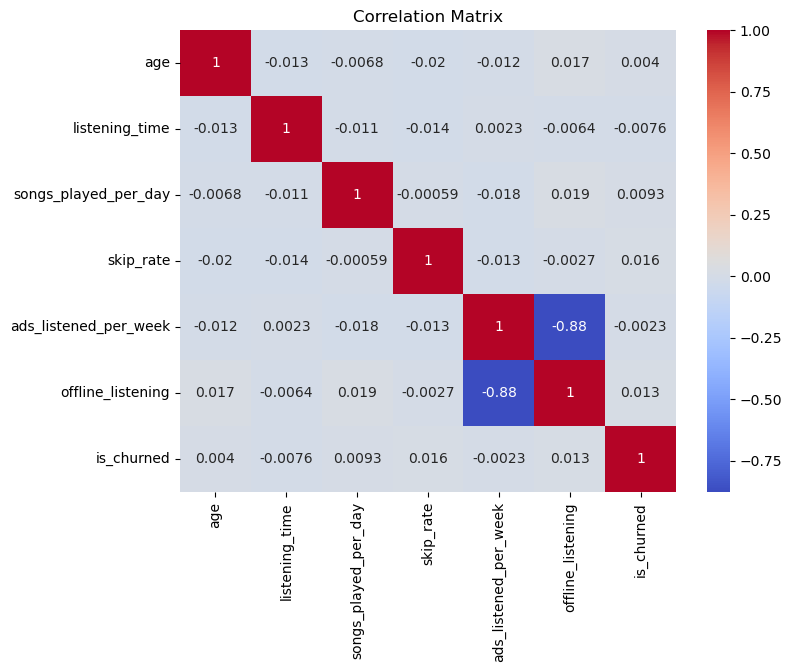

In [9]:
# Visualize correlations among numerical variables.

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

# Demographic and Platform Features

The following analysis examines whether customer churn varies across demographic groups and listening platforms.

The variables analyzed include:

- Gender
- Country
- Device Type

Differences in churn rates across these groups may indicate customer segments that are more or less likely to discontinue their Spotify subscription.

In [11]:
# Calculate churn rates by gender, country, and device type.

for col in ['gender', 'country', 'device_type']:
    
    print(f"\n{col.upper()}")
    
    display(
        pd.crosstab(
            spotify_df[col],
            spotify_df['is_churned'],
            normalize='index'
        ) * 100
    )


GENDER


is_churned,0,1
gender,,
Female,73.711922,26.288078
Male,74.804905,25.195095
Other,73.811321,26.188679



COUNTRY


is_churned,0,1
country,,
AU,74.274662,25.725338
CA,75.157233,24.842767
DE,72.709360,27.290640
FR,72.800809,27.199191
IN,75.667656,24.332344
PK,72.472472,27.527528
UK,75.258799,24.741201
US,74.612403,25.387597



DEVICE_TYPE


is_churned,0,1
device_type,,
Desktop,74.262059,25.737941
Mobile,73.105040,26.894960
Web,74.952345,25.047655


## Findings

Churn rates were relatively consistent across gender, country, and device type categories.

- Female and Other customers exhibited slightly higher churn rates than Male customers, but the differences were small.
- Country-level churn rates ranged from approximately 24% to 28%, indicating limited variation across geographic regions.
- Mobile users exhibited a slightly higher churn rate than Desktop and Web users; however, the differences were modest.

Overall, demographic characteristics and device preferences do not appear to have a strong independent relationship with customer churn within this dataset.

# Key Findings and Potential Features for Modeling

The exploratory analysis identified generally weak relationships between the available predictor variables and customer churn.

Key findings include:

- No numerical variable exhibited a strong linear relationship with churn.
- Churn rates remained relatively consistent across subscription types, genders, countries, and device types.
- The strongest observed relationship within the dataset was between ads_listened_per_week and offline_listening (r = -0.878), indicating that customers who utilize offline listening tend to listen to fewer advertisements.
- Most differences between retained and churned customers were small, suggesting that customer churn may be influenced by combinations of variables rather than any single feature.

Although no strong independent predictors were identified, all features will be retained for future modeling because machine learning algorithms may identify non-linear relationships and interactions that are not evident through exploratory analysis alone.

## EDA Conclusion

The exploratory analysis did not reveal strong independent predictors of customer churn. Future modeling efforts will evaluate whether combinations of variables and more advanced machine learning techniques can identify predictive patterns that are not apparent through univariate analysis or Pearson correlations.